<a href="https://colab.research.google.com/github/shernandez-ucm/AI-MDS/blob/main/tutorial_opencv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial de Transformaciones de Imágenes con Python y OpenCV

Bienvenido a este tutorial sobre transformaciones geométricas de imágenes. Las transformaciones son operaciones fundamentales en visión por computadora que nos permiten modificar la orientación, el tamaño o la perspectiva de una imagen.

En este notebook, exploraremos las siguientes transformaciones utilizando la biblioteca OpenCV:

1.  **Cambio de Escala (Redimensionar)**
2.  **Traslación (Mover)**
3.  **Rotación**
4.  **Transformación Afín**
5.  **Transformación de Perspectiva**

Este tutorial se basa en la [documentación oficial de OpenCV](https://opencv-tutorial.readthedocs.io/en/latest/trans/transform.html#).

## 1. Configuración del Entorno

Primero, importaremos las bibliotecas necesarias. Necesitaremos `cv2` para las operaciones de imagen, `numpy` para manejar las matrices de transformación y `matplotlib` para mostrar las imágenes directamente en el notebook.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuración para que matplotlib muestre las imágenes más grandes
plt.rcParams['figure.figsize'] = (8, 8)

In [16]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg

--2025-09-30 18:48:21--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72937 (71K) [image/jpeg]
Saving to: ‘messi5.jpg.1’

messi5.jpg.1        100%[===================>]  71.23K  --.-KB/s    in 0.01s   

2025-09-30 18:48:21 (5.08 MB/s) - ‘messi5.jpg.1’ saved [72937/72937]



## 2. Cargar una Imagen de Ejemplo

Para este tutorial, usaremos una imagen de ejemplo. Puedes descargarla desde el repositorio de OpenCV o usar cualquier imagen tuya.

**Nota importante:** OpenCV carga las imágenes en formato BGR (Azul, Verde, Rojo), mientras que Matplotlib las muestra en formato RGB (Rojo, Verde, Azul). Por lo tanto, cuando mostremos una imagen a color, necesitaremos convertirla de BGR a RGB.

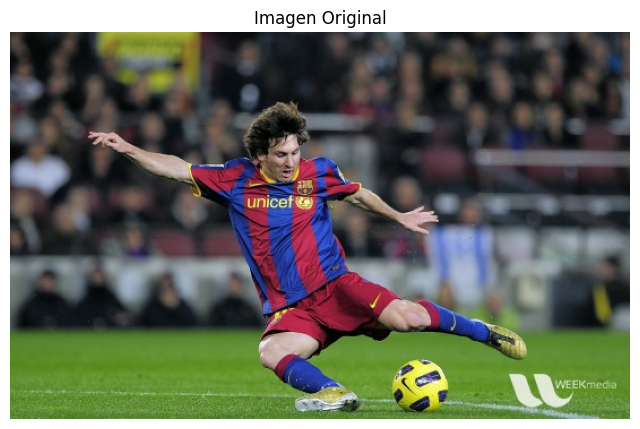

In [15]:
# Descarga la imagen de ejemplo si no la tienes:
# !wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg

# Cargar la imagen
img = cv2.imread('messi5.jpg')

# Convertir de BGR a RGB para mostrarla correctamente con Matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostrar la imagen original
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off') # Ocultar ejes
plt.show()

## 3. Cambio de Escala (Redimensionar)

El cambio de escala se utiliza para modificar el tamaño (ancho y alto) de una imagen. OpenCV proporciona la función `cv2.resize()` para esto.

El tamaño final se puede especificar manualmente o usando un factor de escala. Además, podemos elegir diferentes **métodos de interpolación**:

-   `cv2.INTER_AREA`: Ideal para **reducir** el tamaño de la imagen.
-   `cv2.INTER_CUBIC`: De mayor calidad pero más lento, bueno para **ampliar**.
-   `cv2.INTER_LINEAR`: El método predeterminado, bueno para **ampliar** y con un buen balance de velocidad/calidad.

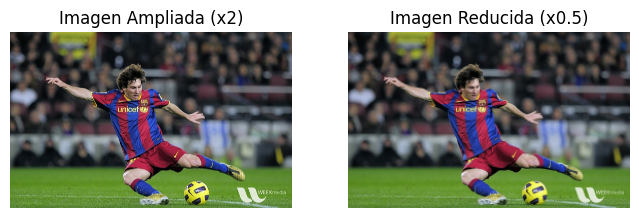

In [7]:
alto, ancho = img.shape[:2]

# Ejemplo 1: Ampliar la imagen al doble de su tamaño
img_ampliada = cv2.resize(img_rgb, None, fx=20, fy=20, interpolation=cv2.INTER_CUBIC)

# Ejemplo 2: Reducir la imagen a la mitad de su tamaño
img_reducida = cv2.resize(img_rgb, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

# Mostrar los resultados
plt.subplot(1, 2, 1)
plt.imshow(img_ampliada)
plt.title('Imagen Ampliada (x2)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_reducida)
plt.title('Imagen Reducida (x0.5)')
plt.axis('off')

plt.show()

## 4. Traslación (Mover una Imagen)

La traslación consiste en mover la ubicación de un objeto en la imagen. Para ello, creamos una **matriz de transformación `M`** de 2x3.

$$ M = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \end{bmatrix} $$

Donde $t_x$ es el desplazamiento en el eje X y $t_y$ es el desplazamiento en el eje Y. Luego, aplicamos esta matriz usando la función `cv2.warpAffine()`.

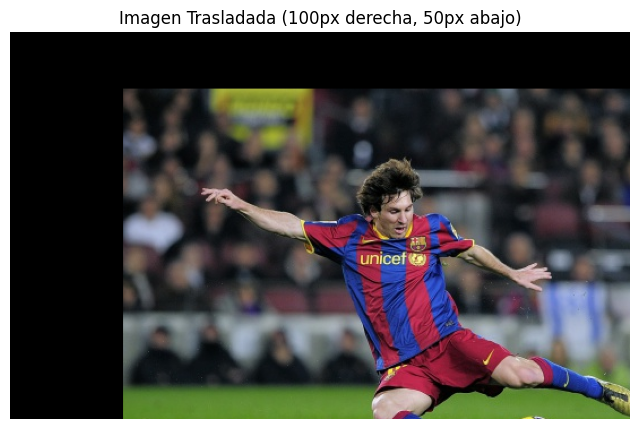

In [10]:
alto, ancho = img.shape[:2]

# Crear la matriz de traslación para mover 100 píxeles a la derecha y 50 hacia abajo
M_traslacion = np.float32([[1, 0, 100], [0, 1, 50]])

# Aplicar la traslación
# El tercer parámetro es el tamaño de la imagen de salida (ancho, alto)
img_trasladada = cv2.warpAffine(img_rgb, M_traslacion, (ancho, alto))

# Mostrar resultado
plt.imshow(img_trasladada)
plt.title('Imagen Trasladada (100px derecha, 50px abajo)')
plt.axis('off')
plt.show()

## 5. Rotación

Para rotar una imagen, necesitamos definir un punto central de rotación, un ángulo y un factor de escala opcional. OpenCV simplifica esto con la función `cv2.getRotationMatrix2D()` que genera la matriz de transformación por nosotros.

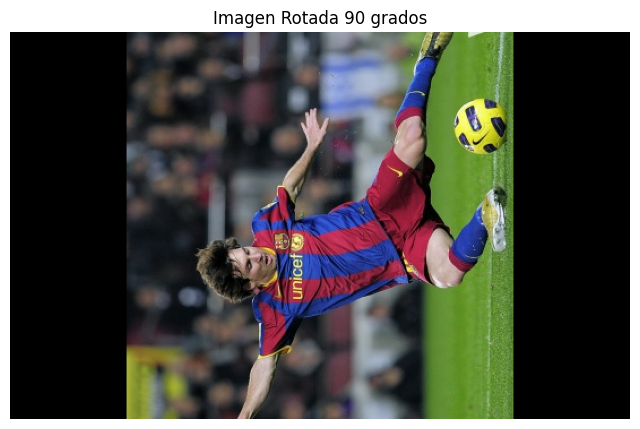

In [11]:
alto, ancho = img.shape[:2]

# Obtener la matriz de rotación
# Parámetros: centro (ancho/2, alto/2), ángulo en grados, escala
M_rotacion = cv2.getRotationMatrix2D((ancho/2, alto/2), 90, 1)

# Aplicar la rotación
img_rotada = cv2.warpAffine(img_rgb, M_rotacion, (ancho, alto))

# Mostrar resultado
plt.imshow(img_rotada)
plt.title('Imagen Rotada 90 grados')
plt.axis('off')
plt.show()

## 6. Transformación Afín

Una transformación afín es una transformación geométrica que conserva las líneas y el paralelismo (las líneas paralelas siguen siendo paralelas). La traslación, la rotación y el escalado son tipos de transformaciones afines.

Para encontrar la matriz de transformación, necesitamos definir **tres puntos** en la imagen de entrada y sus correspondientes ubicaciones en la imagen de salida. OpenCV calculará la matriz adecuada con `cv2.getAffineTransform()`.

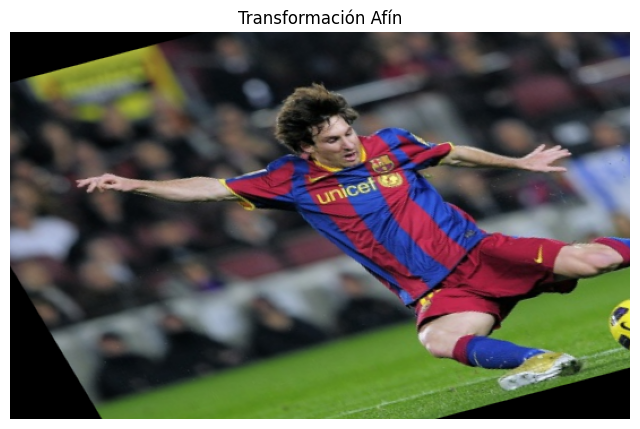

In [12]:
alto, ancho = img_rgb.shape[:2]

# Puntos de origen en la imagen original
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])

# Puntos de destino en la imagen de salida
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])

# Obtener la matriz de transformación afín
M_afin = cv2.getAffineTransform(pts1, pts2)

# Aplicar la transformación
img_afin = cv2.warpAffine(img_rgb, M_afin, (ancho, alto))

# Mostrar resultado
plt.imshow(img_afin)
plt.title('Transformación Afín')
plt.axis('off')
plt.show()

## 7. Transformación de Perspectiva

Para una transformación de perspectiva, necesitamos una matriz de 3x3. Las líneas rectas permanecerán rectas, pero las líneas paralelas podrían converger. Este tipo de transformación es muy útil para obtener una vista "aérea" o frontal de un objeto que fue fotografiado desde un ángulo.

Para encontrar la matriz, necesitamos **cuatro puntos** en el plano de entrada y sus correspondientes en el plano de salida. Usamos `cv2.getPerspectiveTransform()`.

--2025-09-30 18:47:28--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/sudoku.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 250720 (245K) [image/png]
Saving to: ‘sudoku.png’

sudoku.png          100%[===================>] 244.84K  --.-KB/s    in 0.03s   

2025-09-30 18:47:28 (8.84 MB/s) - ‘sudoku.png’ saved [250720/250720]

Download complete.


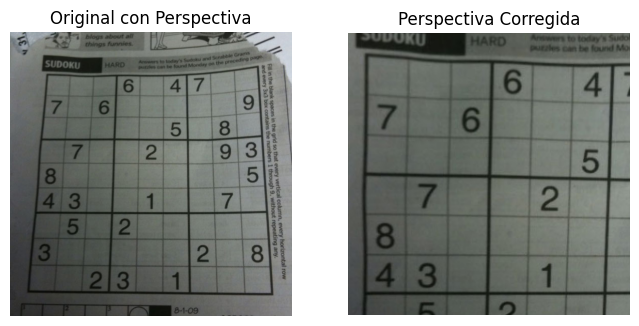

In [14]:
import os

# Define the image file name
sudoku_image_file = 'sudoku.png'

# Download the image if it doesn't exist
if not os.path.exists(sudoku_image_file):
  print(f"Downloading {sudoku_image_file}...")
  !wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/sudoku.png
  print("Download complete.")

# Cargar la imagen
img_sudoku = cv2.imread(sudoku_image_file)

# Check if the image was loaded successfully
if img_sudoku is None:
    print(f"Error loading image: {sudoku_image_file}")
else:
    img_sudoku_rgb = cv2.cvtColor(img_sudoku, cv2.COLOR_BGR2RGB)
    alto, ancho = img_sudoku_rgb.shape[:2]

    # Puntos de origen (las 4 esquinas del sudoku en la imagen original)
    pts1_perspectiva = np.float32([[56, 65], [368, 52], [28, 387], [389, 390]])

    # Puntos de destino (las 4 esquinas de la imagen de salida, formando un rectángulo)
    pts2_perspectiva = np.float32([[0, 0], [300, 0], [0, 300], [300, 300]])

    # Obtener la matriz de transformación de perspectiva
    M_perspectiva = cv2.getPerspectiveTransform(pts1_perspectiva, pts2_perspectiva)

    # Aplicar la transformación
    img_perspectiva = cv2.warpPerspective(img_sudoku_rgb, M_perspectiva, (300, 300))

    # Mostrar los resultados
    plt.subplot(1, 2, 1)
    plt.imshow(img_sudoku_rgb)
    plt.title('Original con Perspectiva')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_perspectiva)
    plt.title('Perspectiva Corregida')
    plt.axis('off')

    plt.show()

## Conclusión

¡Felicidades! Has aprendido a aplicar las transformaciones geométricas más comunes en visión por computadora usando Python y OpenCV. Estas técnicas son la base para tareas más complejas como el registro de imágenes, la corrección de distorsiones y el aumento de datos (*data augmentation*) para entrenar modelos de deep learning.